<a href="https://colab.research.google.com/github/a4kashhh/MaxBetweennessGNN/blob/main/DeepLearning_GNN_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter number of nodes: 100
Enter number of edges: 300
Generated Graph
Nodes: 100
Edges: 291
Epoch:000, Loss:2.6927, Acc:0.6440
Epoch:010, Loss:2.5458, Acc:0.6730
Epoch:020, Loss:2.3306, Acc:0.8220
Epoch:030, Loss:2.1611, Acc:0.8370
Epoch:040, Loss:2.0674, Acc:0.8840
Epoch:050, Loss:1.9930, Acc:0.8900
Epoch:060, Loss:1.9251, Acc:0.8910
Epoch:070, Loss:1.8728, Acc:0.9050
Epoch:080, Loss:1.8198, Acc:0.9020
Epoch:090, Loss:1.7797, Acc:0.9170
Epoch:100, Loss:1.7661, Acc:0.9190
Epoch:110, Loss:1.7103, Acc:0.9290
Epoch:120, Loss:1.7094, Acc:0.9360
Epoch:130, Loss:1.6512, Acc:0.9440
Epoch:140, Loss:1.6024, Acc:0.9550
Epoch:150, Loss:1.6197, Acc:0.9530
Epoch:160, Loss:1.5921, Acc:0.9620
Epoch:170, Loss:1.5684, Acc:0.9660
Epoch:180, Loss:1.5481, Acc:0.9790
Epoch:190, Loss:1.5648, Acc:0.9760
Predicted Positives: 307
Actual Positives: 300

Final Results
Accuracy : 0.993
Precision: 0.9771986970684039
Recall   : 1.0
F1 Score : 0.9884678747940692


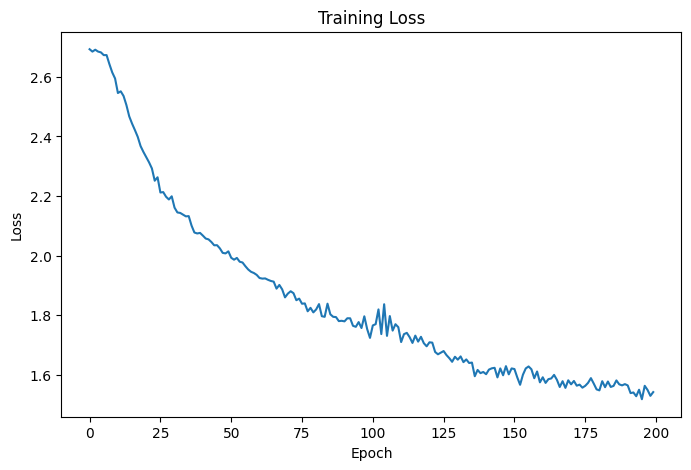

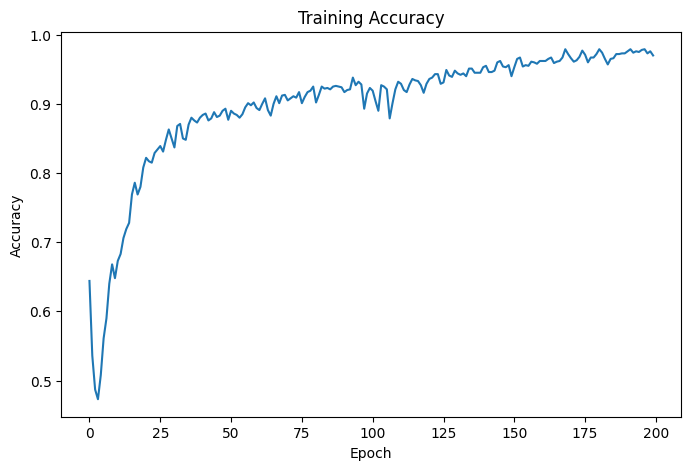

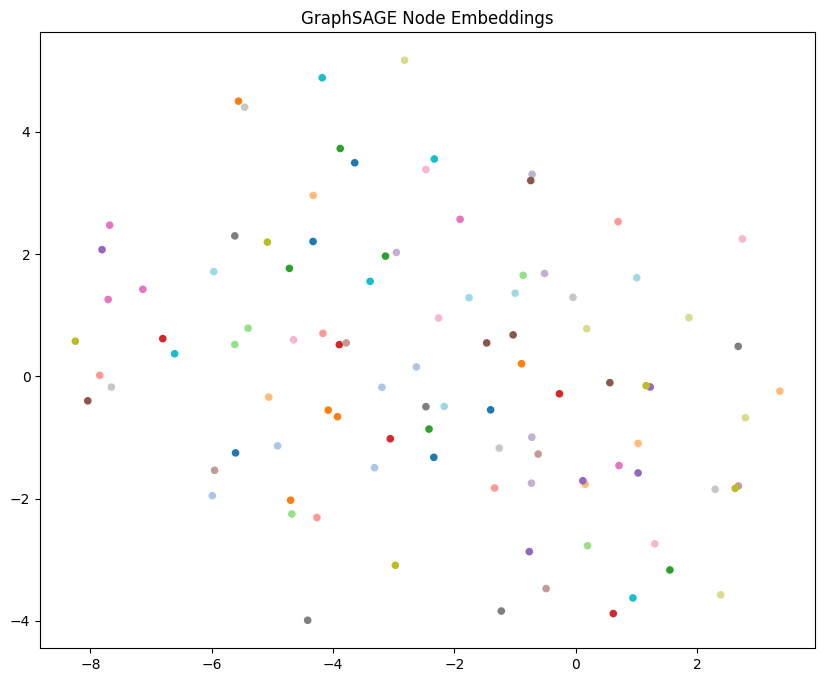

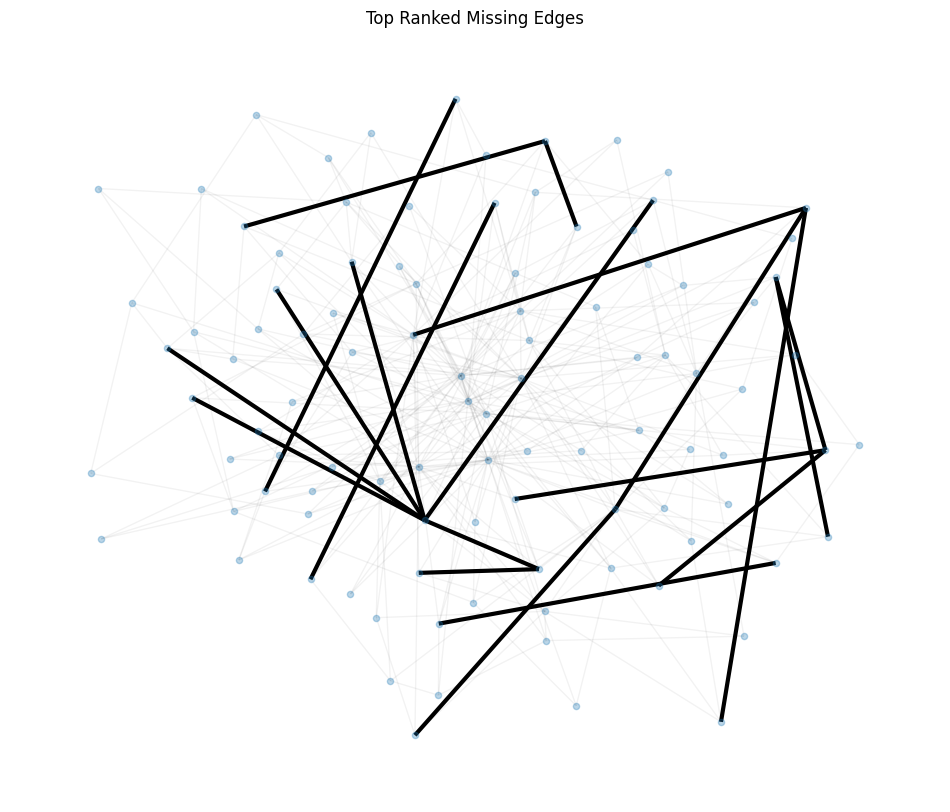


Top 20 Predicted Edges
(59, 70) Score: 2.0202262
(84, 93) Score: 2.0144746
(75, 94) Score: 1.8414708
(8, 70) Score: 1.757341
(17, 58) Score: 1.5166503
(84, 92) Score: 1.4912676
(62, 68) Score: 1.482206
(76, 97) Score: 1.4646152
(10, 70) Score: 1.417362
(8, 87) Score: 1.389839
(75, 82) Score: 1.3729299
(35, 94) Score: 1.342536
(9, 97) Score: 1.3380346
(72, 98) Score: 1.3264366
(44, 80) Score: 1.2889777
(69, 97) Score: 1.2765651
(65, 97) Score: 1.2725478
(58, 97) Score: 1.2486156
(75, 83) Score: 1.2143205
(28, 97) Score: 1.2058848


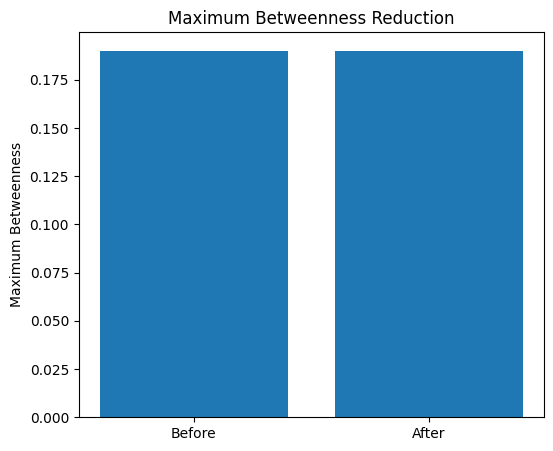

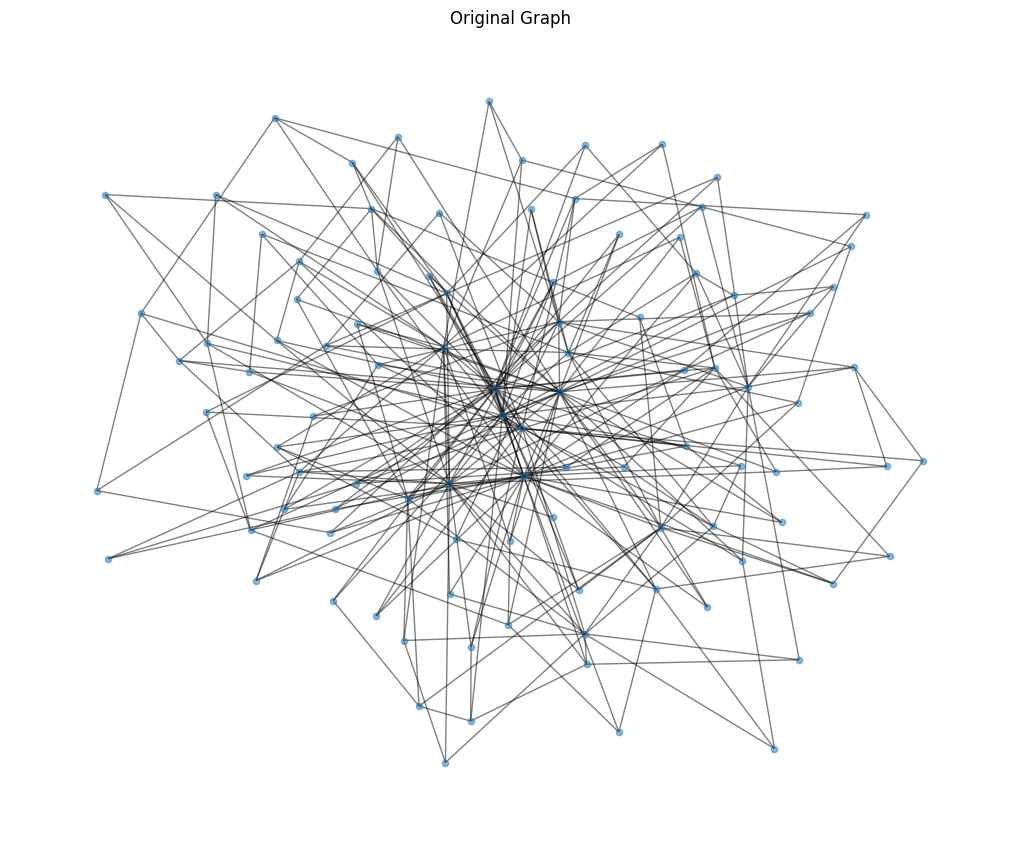

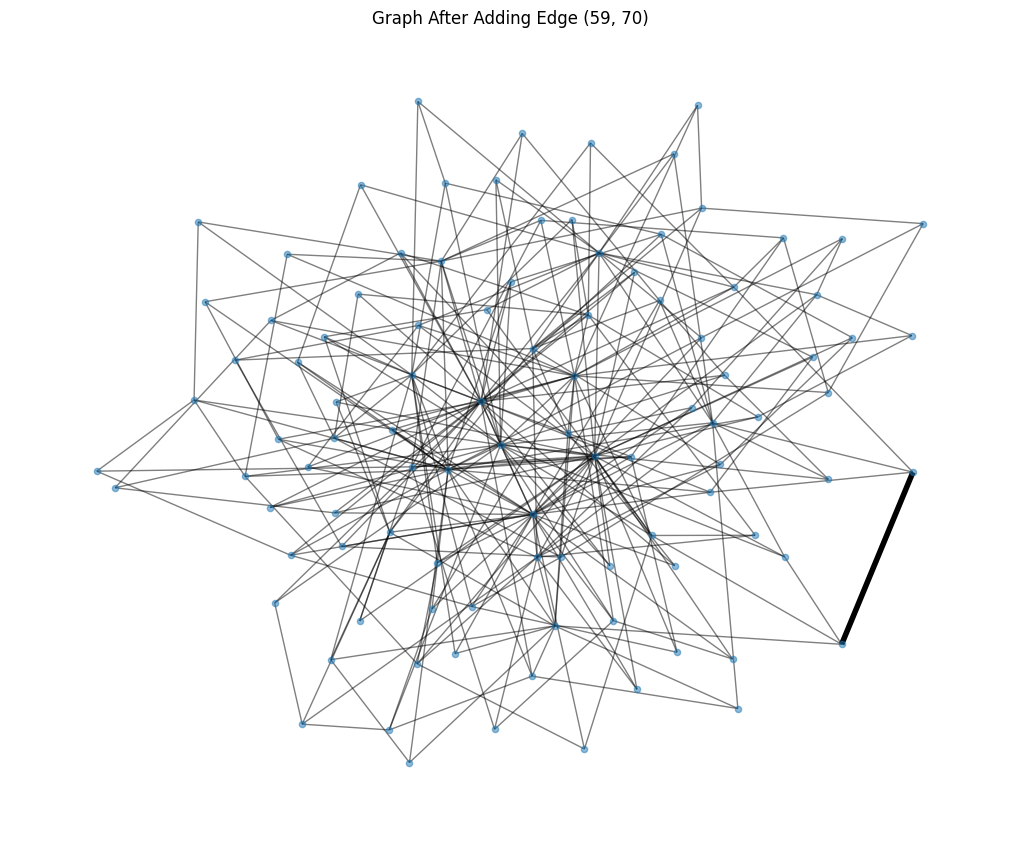


Best Edge Found: (59, 70)
Maximum BC Before: 0.19010729893421358
Maximum BC After: 0.18999540436927467
Reduction: 0.058858636942059145 %


In [7]:
!pip install torch_geometric

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.manifold import TSNE

num_nodes=int(input("Enter number of nodes: "))
num_edges=int(input("Enter number of edges: "))

m=max(1,num_edges//num_nodes)
G=nx.barabasi_albert_graph(n=num_nodes,m=m,seed=42)

print("Generated Graph")
print("Nodes:",G.number_of_nodes())
print("Edges:",G.number_of_edges())

pos=nx.spring_layout(G,k=0.15,seed=42)

feature_dim=32

x=torch.randn((num_nodes,feature_dim),dtype=torch.float)

candidate_edges=[]

while len(candidate_edges)<1000:
    u=np.random.randint(num_nodes)
    v=np.random.randint(num_nodes)

    if u!=v and not G.has_edge(u,v):
        edge=tuple(sorted((u,v)))

        if edge not in candidate_edges:
            candidate_edges.append(edge)

candidate_edges=torch.tensor(candidate_edges,dtype=torch.long)

base_bc=max(nx.betweenness_centrality(G).values())

edge_scores=[]

for edge in candidate_edges.tolist():
    G2=G.copy()
    G2.add_edge(edge[0],edge[1])

    new_bc=max(nx.betweenness_centrality(G2).values())

    reduction=base_bc-new_bc

    edge_scores.append(reduction)

edge_scores=np.array(edge_scores)

threshold=np.percentile(edge_scores,70)

labels=np.where(edge_scores>=threshold,1,0)

labels=torch.tensor(labels,dtype=torch.long)

edge_scores=torch.tensor(edge_scores,dtype=torch.float)

triplets=[]

for _ in range(1000):
    a=np.random.randint(len(candidate_edges))
    b=np.random.randint(len(candidate_edges))
    c=np.random.randint(len(candidate_edges))

    triplets.append([a,b,c])

triplets=torch.tensor(triplets)

adj=torch.tensor(nx.to_numpy_array(G),dtype=torch.float)

class SimpleGraphSAGE(nn.Module):
    def __init__(self,input_dim,hidden_dim):
        super(SimpleGraphSAGE,self).__init__()
        self.linear_self=nn.Linear(input_dim,hidden_dim)
        self.linear_neigh=nn.Linear(input_dim,hidden_dim)

    def forward(self,x,adj):
        neighbor_sum=torch.matmul(adj,x)
        degree=adj.sum(dim=1,keepdim=True)
        neighbor_mean=neighbor_sum/(degree+1e-10)
        self_feature=self.linear_self(x)
        neigh_feature=self.linear_neigh(neighbor_mean)
        out=self_feature+neigh_feature
        return F.relu(out)

class MLPClassifier(nn.Module):
    def __init__(self,input_dim):
        super(MLPClassifier,self).__init__()
        self.fc1=nn.Linear(input_dim,64)
        self.fc2=nn.Linear(64,32)
        self.fc3=nn.Linear(32,2)

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=F.relu(self.fc2(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=self.fc3(x)
        return x

class MLPRanker(nn.Module):
    def __init__(self,input_dim):
        super(MLPRanker,self).__init__()
        self.fc1=nn.Linear(input_dim,64)
        self.fc2=nn.Linear(64,32)
        self.fc3=nn.Linear(32,1)

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=F.relu(self.fc2(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=self.fc3(x)
        return x
class BetweennessModel(nn.Module):
    def __init__(self,node_feat_dim,hidden_dim):
        super(BetweennessModel,self).__init__()
        self.gnn1=SimpleGraphSAGE(node_feat_dim,hidden_dim)
        self.gnn2=SimpleGraphSAGE(hidden_dim,hidden_dim)
        self.classifier=MLPClassifier(hidden_dim*2)
        self.ranker=MLPRanker(hidden_dim*2)

    def forward(self,x,adj,edge_pairs):
        h=self.gnn1(x,adj)
        h=self.gnn2(h,adj)

        u=edge_pairs[:,0]
        v=edge_pairs[:,1]

        edge_embeddings=torch.cat([h[u],h[v]],dim=1)

        class_probs=self.classifier(edge_embeddings)
        rank_scores=self.ranker(edge_embeddings)

        return class_probs,rank_scores,h

def classification_loss(pred_probs,labels):
    class_counts=torch.bincount(labels)
    weights=1.0/class_counts.float()
    weights=weights/weights.sum()
    return F.cross_entropy(pred_probs,labels,weight=weights)

def triplet_margin_loss(scores,triplets,margin=1.0):
    loss=0

    for t in triplets:
        m,n,o=t

        sm=scores[m]
        sn=scores[n]
        so=scores[o]

        loss1=torch.maximum(torch.tensor(0.0),-(sm-sn)+margin)
        loss2=torch.maximum(torch.tensor(0.0),-(sn-so)+margin)

        loss+=loss1+loss2

    return loss/len(triplets)

model=BetweennessModel(node_feat_dim=feature_dim,hidden_dim=32)

optimizer=torch.optim.Adam(model.parameters(),lr=0.005)

loss_history=[]
acc_history=[]

for epoch in range(200):

    model.train()

    optimizer.zero_grad()

    class_probs,rank_scores,h=model(x,adj,candidate_edges)

    loss_cls=classification_loss(class_probs,labels)

    loss_rank=triplet_margin_loss(rank_scores.squeeze(),triplets)

    total_loss=loss_cls+loss_rank

    total_loss.backward()

    optimizer.step()

    pred=torch.argmax(class_probs,dim=1)

    acc=accuracy_score(labels.numpy(),pred.detach().numpy())

    loss_history.append(total_loss.item())

    acc_history.append(acc)

    if epoch%10==0:
        print(f"Epoch:{epoch:03d}, Loss:{total_loss.item():.4f}, Acc:{acc:.4f}")

model.eval()

with torch.no_grad():
    class_probs,rank_scores,h=model(x,adj,candidate_edges)

pred=torch.argmax(class_probs,dim=1)

print("Predicted Positives:",pred.sum().item())
print("Actual Positives:",labels.sum().item())

acc=accuracy_score(labels.numpy(),pred.detach().numpy())

prec=precision_score(labels.numpy(),pred.detach().numpy(),zero_division=0)

rec=recall_score(labels.numpy(),pred.detach().numpy(),zero_division=0)

f1=f1_score(labels.numpy(),pred.detach().numpy(),zero_division=0)

print("\nFinal Results")
print("======================")
print("Accuracy :",acc)
print("Precision:",prec)
print("Recall   :",rec)
print("F1 Score :",f1)

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(acc_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

embeddings=h.detach().numpy()

z=TSNE(n_components=2,random_state=42).fit_transform(embeddings)

plt.figure(figsize=(10,8))
plt.scatter(z[:,0],z[:,1],c=np.arange(num_nodes),cmap="tab20",s=20)
plt.title("GraphSAGE Node Embeddings")
plt.show()

scores=rank_scores.squeeze().detach().numpy()

top_k=20

top_indices=np.argsort(scores)[::-1][:top_k]

top_edges=[]

for idx in top_indices:
    edge=tuple(candidate_edges[idx].tolist())
    top_edges.append(edge)

plt.figure(figsize=(12,10))
nx.draw_networkx_nodes(G,pos,node_size=20,alpha=0.3)
nx.draw_networkx_edges(G,pos,alpha=0.05)
nx.draw_networkx_edges(G,pos,edgelist=top_edges,width=3)
plt.title("Top Ranked Missing Edges")
plt.axis("off")
plt.show()

print("\nTop 20 Predicted Edges")
print("======================")

for idx in top_indices:
    edge=tuple(candidate_edges[idx].tolist())
    print(edge,"Score:",scores[idx])

best_idx=np.argmax(scores)

best_edge=tuple(candidate_edges[best_idx].tolist())

G_best=G.copy()

G_best.add_edge(best_edge[0],best_edge[1])

best_bc=max(nx.betweenness_centrality(G_best).values())

plt.figure(figsize=(6,5))
plt.bar(["Before","After"],[base_bc,best_bc])
plt.ylabel("Maximum Betweenness")
plt.title("Maximum Betweenness Reduction")
plt.show()

plt.figure(figsize=(10,8))
nx.draw(G,pos,node_size=20,alpha=0.5)
plt.title("Original Graph")
plt.show()

pos2=nx.spring_layout(G_best,seed=42)

plt.figure(figsize=(10,8))
nx.draw(G_best,pos2,node_size=20,alpha=0.5)
nx.draw_networkx_edges(G_best,pos2,edgelist=[best_edge],width=4)
plt.title(f"Graph After Adding Edge {best_edge}")
plt.show()

print("\nBest Edge Found:",best_edge)
print("Maximum BC Before:",base_bc)
print("Maximum BC After:",best_bc)
print("Reduction:",((base_bc-best_bc)/(base_bc+1e-10))*100,"%")